># Reavaliação do dataset Iris com SVM

>#### **Aluno:** Maria Fernanda Sayuri **Turma:** 6A - manhã
>**Objetivo:** Este notebook tem como objetivo realizar a análise exploratória do dataset Iris (via Kaggle) e desenvolver um modelo de classificação utilizando o algoritmo SVM.

## Importação das bibliotecas
*Primeiro, importa as bibliotecas necessárias para manipulação/visualização de dados e as ferramentas de Machine Learning do scikit-learn para construção e avaliação do modelo SVM*

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

plt.rcParams["figure.figsize"] = (8, 5)
print("bibliotecas importadas!")

bibliotecas importadas!


## Carregamento dos dados do dataset
*Faz a leitura dos dados através do arquivo .csv do Kaggle, e não do
load_iris()*

In [2]:
caminho_arq = "/kaggle/input/datasets/menegidio/iris-species/Iris.csv"

# le o arquivo com pandas
df = pd.read_csv(caminho_arq)
# exibe
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


## Análise exploratória de dados (EDA)
*Antes de treinar o modelo, verifica como é a estrutura, os tipos de dados/colunas presentes, se tem valor faltando e possíveis valores nulos no dataset.*

In [3]:
print("Dimensao do dataset:", df.shape)

# exibe os tipos de dados presentes no df
print("\nInformacoes estruturais:")
df.info()

# exibe qtd de flores de cada especie (coluna variavel-alvo)
print("\nContagem por especie:")
print(df['Species'].value_counts())

# exibe resumo estatistico
print("\nResumo estatistico:")
display(df.describe())

Dimensao do dataset: (150, 6)

Informacoes estruturais:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB

Contagem por especie:
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

Resumo estatistico:


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


*Após a análise, não tem valor faltando e as 3 espécies têm 50 amostras cada (está balanceado).*

### *=> Exploração visual dos dados*
*Cria um gráfico de dispersão para visualizar a relação de Comprimento x Largura das pétalas*


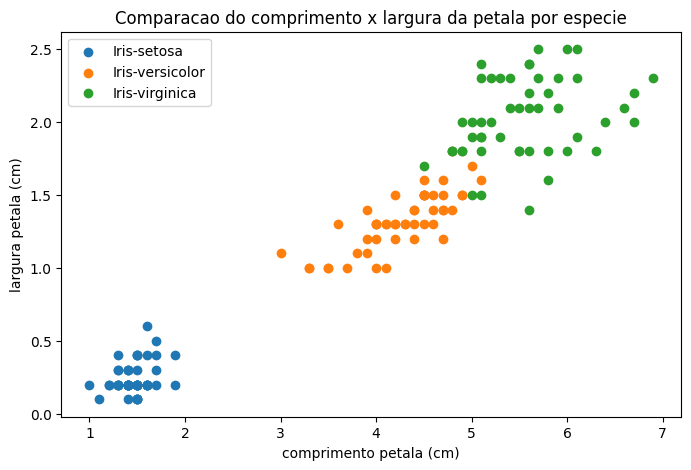

In [4]:
plt.figure()
for especie, dados_esp in df.groupby('Species'):
    plt.scatter(dados_esp['PetalLengthCm'], dados_esp['PetalWidthCm'], label=especie)

plt.xlabel('comprimento petala (cm)')
plt.ylabel('largura petala (cm)')
plt.title('Comparacao do comprimento x largura da petala por especie')
plt.legend()
plt.show()

## Divisão dos dados em treino e teste
*São separados 80% para treino e 20% para teste, com stratify=y para manter a
proporção das 3 espécies nos dois grupos.*

In [5]:
# define as variaveis preditoras (remove o Id e a especie)
X = df.drop(columns=['Id', 'Species'])

# define a variavel-alvo
y = df['Species']

# faz a divisao dos dados (treino e teste)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("\nDistribuicao y_train:")
print(y_train.value_counts())
print("\nDistribuicao y_test:")
print(y_test.value_counts())

X_train: (120, 4)
X_test : (30, 4)

Distribuicao y_train:
Species
Iris-setosa        40
Iris-virginica     40
Iris-versicolor    40
Name: count, dtype: int64

Distribuicao y_test:
Species
Iris-setosa        10
Iris-virginica     10
Iris-versicolor    10
Name: count, dtype: int64


## Treino SVM linear com Pipeline
*É criado um Pipeline que padroniza os dados e já treina o SVM linear em
seguida. Usar Pipeline evita erro de vazar informação do teste para o treino.*

In [6]:
pipeline_svm_linear = Pipeline([
    ('scaler', StandardScaler()),
    ('modelo_svm', SVC(kernel='linear', C=1.0, random_state=42))
])

# treino e previsoes
pipeline_svm_linear.fit(X_train, y_train)

y_previsao_linear = pipeline_svm_linear.predict(X_test)

acuracia_lin = accuracy_score(y_test, y_previsao_linear)
print(f"Acuracia do SVM linear: {acuracia_lin*100:.2f}%")

# outras metricas
print("\nRelatorio de classificacao SVM linear:\n")
print(classification_report(y_test, y_previsao_linear))

Acuracia do SVM linear: 100.00%

Relatorio de classificacao SVM linear:

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00        10
 Iris-virginica       1.00      1.00      1.00        10

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



## Validação cruzada do SVM linear
*Utiliza a Validação Cruzada com 5 divisões diferentes, para ver se o resultado se mantém e garantir que o modelo não deu sorte na divisão.*

In [7]:
validacao_cruz = cross_val_score(pipeline_svm_linear, X, y, cv = 5)
print("Acuracia em cada verificacao: ", validacao_cruz)
print(f"Media: {validacao_cruz.mean()*100:.2f}%")
print(f"Desvio padrao: {validacao_cruz.std()*100:.2f}%")

Acuracia em cada verificacao:  [0.96666667 1.         0.93333333 0.93333333 1.        ]
Media: 96.67%
Desvio padrao: 2.98%


## Matriz de Confusão do SVM linear
*A matriz mostra os acertos (na diagonal) e os erros (fora dela) por
espécie.*

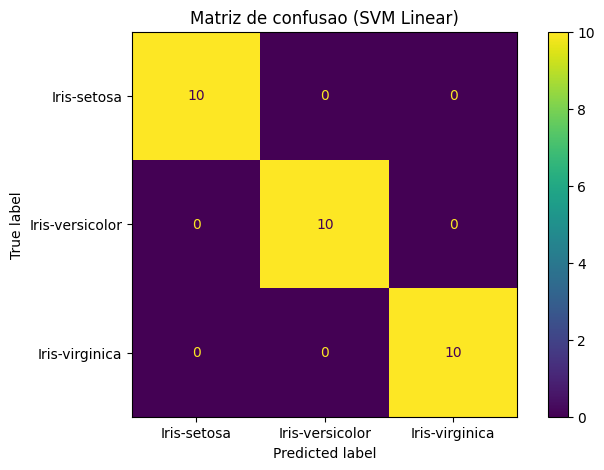

In [8]:
mc_linear = confusion_matrix(y_test, y_previsao_linear, labels=["Iris-setosa", "Iris-versicolor", "Iris-virginica"])
visu = ConfusionMatrixDisplay(confusion_matrix=mc_linear, display_labels=["Iris-setosa", "Iris-versicolor", "Iris-virginica"])
visu.plot()
plt.title("Matriz de confusao (SVM Linear)")
plt.show()

## Treino SVM não linear com kernel RBF
*Agora, o teste será com kernel RBF, que permite fronteiras mais curvas/complexas, para ver se melhora o resultado ou não.*

In [9]:
pipeline_svm_rbf = Pipeline([
    ("scaler", StandardScaler()),
    ("modelo_svm", SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42))
])

# treino e previsoes
pipeline_svm_rbf.fit(X_train, y_train)

y_previsao_rbf = pipeline_svm_rbf.predict(X_test)

acuracia_rbf = accuracy_score(y_test, y_previsao_rbf)
print(f"Acuracia do SVM com kernel RBF: {acuracia_rbf*100:.2f}%")

# outras metricas
print("\nRelatorio de classificacao SVM com kernel RBF:\n")
print(classification_report(y_test, y_previsao_rbf))

Acuracia do SVM com kernel RBF: 96.67%

Relatorio de classificacao SVM com kernel RBF:

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30



*Aqui resultou uma acurácia um pouco menor que o linear, e confundiu algumas versicolor com virginica. Ou seja, a complexidade extra do RBF não
ajudou muito nesse caso.*

## Validação cruzada do SVM não linear com kernel RBF

In [10]:
validacao_cruz_rbf = cross_val_score(pipeline_svm_rbf, X, y, cv = 5)
print("Acuracia em cada verificacao: ", validacao_cruz_rbf)
print(f"Media: {validacao_cruz_rbf.mean()*100:.2f}%")
print(f"Desvio padrao: {validacao_cruz_rbf.std()*100:.2f}%")

Acuracia em cada verificacao:  [0.96666667 0.96666667 0.96666667 0.93333333 1.        ]
Media: 96.67%
Desvio padrao: 2.11%


## Matriz de Confusão do SVM não linear com kernel RBF

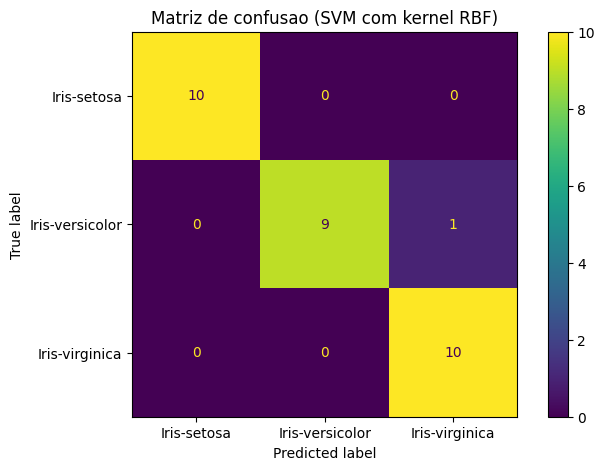

In [11]:
mc_rbf = confusion_matrix(y_test, y_previsao_rbf, labels=["Iris-setosa", "Iris-versicolor", "Iris-virginica"])
visu = ConfusionMatrixDisplay(confusion_matrix=mc_rbf, display_labels=["Iris-setosa", "Iris-versicolor", "Iris-virginica"])
visu.plot()
plt.title("Matriz de confusao (SVM com kernel RBF)")
plt.show()

## Conclusão
*O SVM linear foi melhor que o RBF nesse caso (100% x 96,67% de acurácia), e a
validação cruzada confirma que os dois se mantêm estáveis em diferentes
divisões dos dados. Ou seja, o modelo mais complexo (RBF) não
necessariamente é melhor (quando as classes já são bem separadas). Em dados reais e mais bagunçados, isso pode mudar.*